# Spatial Biomarker Transformer — Demo

This notebook walks through the full training pipeline:
1. Configuration
2. Data loading (`three_dataset_demo`)
3. Model initialization (student + teacher)
4. Training loop (reconstruction + distillation loss)
5. Visualization of training curves and biomarker reconstruction quality


## 0. Environment Check

In [28]:
import os, sys

# Ensure the working directory is the project root (containing model.py, config.py, etc.)
NOTEBOOK_DIR = os.path.abspath('.')

if os.path.exists(os.path.join(NOTEBOOK_DIR, 'model.py')):
    PROJECT_ROOT = NOTEBOOK_DIR
else:
    PROJECT_ROOT = os.path.dirname(NOTEBOOK_DIR)

if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

os.chdir(PROJECT_ROOT)
print(f'Working directory : {os.getcwd()}')
print(f'model.py found    : {os.path.exists("model.py")}')
print(f'Demo data found   : {os.path.exists("three_dataset_demo")}')

Working directory : /Users/jiangwengyao/Desktop/spatial-biomarker-transformer
model.py found    : True
Demo data found   : True


In [29]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

print(f'PyTorch version : {torch.__version__}')
print(f'CUDA available  : {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU             : {torch.cuda.get_device_name(0)}')

PyTorch version : 2.6.0
CUDA available  : False


## 1. Bootstrap: Generate `biomarker_sequences.csv`

`data_loader.py` requires a `biomarker_sequences.csv` to build the list of valid biomarkers.
If this file is missing, all regions fail silently with a `KeyError`.

This cell scans the demo data, collects all biomarker names, and creates the file automatically.

In [30]:
import pandas as pd
import glob

DATA_ROOT = 'three_dataset_demo'
SEQ_FILE  = 'biomarker_sequences.csv'

if os.path.exists(SEQ_FILE):
    print(f'{SEQ_FILE} already exists — skipping generation.')
    existing = pd.read_csv(SEQ_FILE)
    print(f'  Contains {len(existing)} entries.')
else:
    # Collect all unique biomarker names across every expression.csv in the demo
    all_biomarkers = set()
    expr_files = glob.glob(os.path.join(DATA_ROOT, '**', 'expression.csv'), recursive=True)
    print(f'Found {len(expr_files)} expression.csv files')

    for path in expr_files:
        df = pd.read_csv(path, nrows=0)  # header only
        for col in df.columns:
            col_lower = col.lower()
            is_cell_id = col in ['cell_id','cellid','id','cell','Cell_ID','CellID'] \
                         or ('cell' in col_lower and 'id' in col_lower)
            if not is_cell_id and not col.startswith('Unnamed'):
                all_biomarkers.add(col)

    print(f'Total unique biomarkers found: {len(all_biomarkers)}')
    print(f'Sample: {sorted(all_biomarkers)[:8]}')

    # Write the CSV: biomarker name | amino_acid_seq (NaN = legit but no sequence)
    seq_df = pd.DataFrame({
        'biomarker_name': sorted(all_biomarkers),
        'amino_acid_seq': [float('nan')] * len(all_biomarkers)
    })
    seq_df.to_csv(SEQ_FILE, index=False)
    print(f'\n{SEQ_FILE} created with {len(seq_df)} entries.')

biomarker_sequences.csv already exists — skipping generation.
  Contains 41 entries.


## 2. Configuration

In [32]:
from config import Config
config = Config()
config.device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

# ── Biomarker embedding method ────────────────────
# 'learnable' : one trainable vector per biomarker (recommended for demo)
# 'onehot'    : fixed one-hot encoding, not trainable
# 'esm'       : protein language model (requires large GPU + sequences)
config.embedding_method = 'learnable'
config.learnable_embedding_dim = 512

# ── Model architecture ────────────────────────────
config.d_model = 256
config.nhead = 8
config.num_encoder_layers = 4
config.dim_feedforward = 512
config.dropout = 0.1
config.positional_embedder = 'rotational'

# ── Spatial sampling 
config.max_neighbors = 50
config.neighbor_distance_threshold = 150
config.min_cells_per_region = 100

# ── Intensity masking 
config.enable_center_intensity_masking = True
config.center_intensity_mask_probability = 1.0
config.center_intensity_min_mask_ratio = 0.8
config.center_intensity_max_mask_ratio = 0.8
config.center_intensity_mask_value = 0.0
config.center_mask_strategy = 'random'
config.preserve_top_biomarkers = 0

config.enable_neighbor_intensity_masking = True
config.neighbor_intensity_mask_probability = 1.0
config.neighbor_intensity_min_mask_ratio = 0.2
config.neighbor_intensity_max_mask_ratio = 0.8
config.neighbor_intensity_mask_value = 0.0
config.neighbor_mask_strategy = 'random'

# ── Training hyperparameters
config.lr = 1e-4
config.initial_lr = 1e-6
config.weight_decay = 5e-4
config.warmup_steps = 200
config.ema_momentum = 0.999
config.reconstruction_loss_weight = 0.8
config.distillation_loss_weight = 0.2
config.num_epochs = 10
config.batch_size = 64
config.n_subgraphs_per_region = 100

# ── File names
config.position_filename = 'cell_data.csv'
config.biomarker_filename = 'expression.csv'
config.celltype_filename = 'cell_type.csv'
config.use_cell_types = True
config.biomarker_name_mapping_file = 'biomarker_name_mapping.json'
config.biomarker_sequence_file = SEQ_FILE
config.normalize_masked_expression = False
config.spec_index_recon = False

print(f'Device           : {config.device}')
print(f'Embedding method : {config.embedding_method}')
print(f'Transformer      : {config.num_encoder_layers} layers, d_model={config.d_model}, nhead={config.nhead}')

Device           : cpu
Embedding method : learnable
Transformer      : 4 layers, d_model=256, nhead=8


## 3. Data Loading

In [33]:
from data_loader import SpatialBiomarkerDataset

dataset = SpatialBiomarkerDataset(DATA_ROOT, config=config)

assert len(dataset) > 0, (
    'No regions loaded! Check the error messages above for details.'
)

print('\n── Dataset Statistics ')
stats = dataset.get_dataset_statistics()
print(f'Total regions      : {stats["total_regions"]}')
print(f'Total biomarkers   : {stats["total_biomarkers"]}')
print(f'Cells per region   : {stats["mean_cells_per_region"]:.0f} ± {stats["std_cells_per_region"]:.0f}')
print(f'Min / Max cells    : {stats["min_cells_per_region"]} / {stats["max_cells_per_region"]}')
print(f'\nStudy breakdown:')
for study, count in stats['studies'].items():
    print(f'  {study}: {count} regions')
if config.use_cell_types:
    print(f'\nTotal cell types   : {stats["total_cell_types"]}')
    print('Cell types:', sorted(stats.get('cell_types', [])))

Loaded biomarker info from biomarker_sequences.csv
  - Valid biomarkers: 41
  - Invalid biomarkers: 0
Processing study: s240
Loaded 308 regions from three_dataset_demo
Found 41 unique biomarkers
Found 17 unique cell types

── Dataset Statistics 
Total regions      : 308
Total biomarkers   : 41
Cells per region   : 7030 ± 3759
Min / Max cells    : 1065 / 19826

Study breakdown:
  s240: 308 regions

Total cell types   : 17
Cell types: ['APC', 'B cell', 'CD4 T cell', 'CD8 T cell', 'Granulocyte', 'Lymph vessel', 'Macrophage', 'Naive immune cell', 'Stromal / Fibroblast', 'Tumor', 'Tumor (CD15+)', 'Tumor (CD20+)', 'Tumor (CD21+)', 'Tumor (Ki67+)', 'Tumor (Podo+)', 'Unassigned', 'Vessel']


/var/folders/g4/w7sz7ldj4yb673_hlj0jrc700000gn/T/ipykernel_82305/2856688692.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab20', len(unique_types))


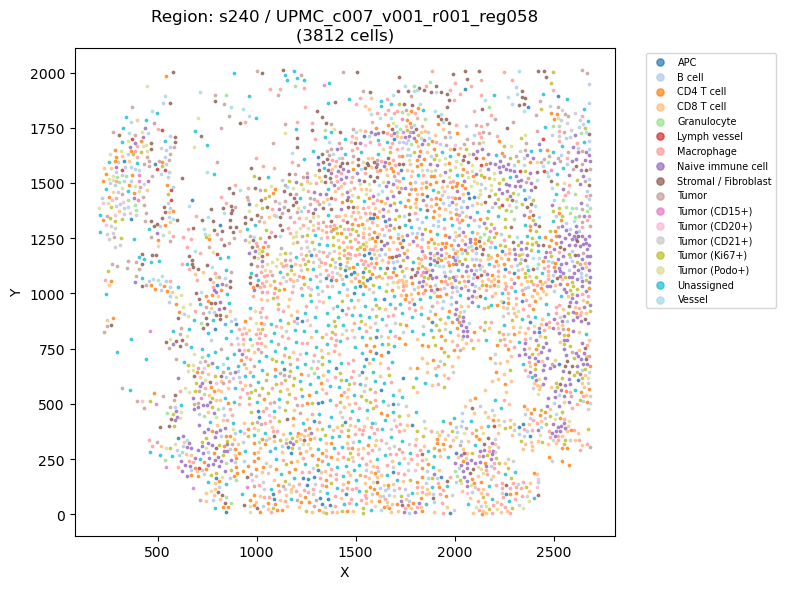

Biomarkers (41): ['CD117', 'CD11b', 'CD11c', 'CD134', 'CD14', 'CD15', 'CD152', 'CD16', 'CD163', 'CD20', 'CD21', 'CD31', 'CD34', 'CD38', 'CD3e', 'CD4', 'CD45', 'CD45RA', 'CD45RO', 'CD47', 'CD49f', 'CD56', 'CD57', 'CD68', 'CD69', 'CD8', 'CollagenIV', 'DAPI', 'FoxP3', 'GranzymeB', 'HLA-DR', 'ICOS', 'Ki67', 'PD1', 'PDL1', 'PanCK', 'Podoplanin', 'TMEM16A', 'Vimentin', 'aSMA', 'p16']


In [21]:
# Visualize the spatial distribution of cells in one region
region = dataset[0]
coords = region['coordinates']
cell_types = region['cell_types']

fig, ax = plt.subplots(figsize=(8, 6))

unique_types = sorted(set(cell_types))
cmap = plt.cm.get_cmap('tab20', len(unique_types))
type_to_color = {t: cmap(i) for i, t in enumerate(unique_types)}

for ct in unique_types:
    mask = [i for i, t in enumerate(cell_types) if t == ct]
    ax.scatter(coords[mask, 0], coords[mask, 1],
               c=[type_to_color[ct]], label=ct, s=3, alpha=0.7)

ax.set_title(f'Region: {region["study_name"]} / {region["region_name"]}\n({len(coords)} cells)')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=7, markerscale=3)
plt.tight_layout()
plt.show()
print(f'Biomarkers ({len(region["biomarkers"])}): {region["biomarkers"]}')

### Subgraph visualization: radius, center & neighbors

Sample one subgraph from the same region, then plot the region with:
- **Grey**: all cells in the region  
- **Circle**: neighbor radius (from `config.neighbor_distance_threshold`)  
- **Red star**: center cell  
- **Blue dots**: neighbors in the subgraph

/var/folders/g4/w7sz7ldj4yb673_hlj0jrc700000gn/T/ipykernel_82305/4124159839.py:23: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab20', max(len(unique_types), 1))


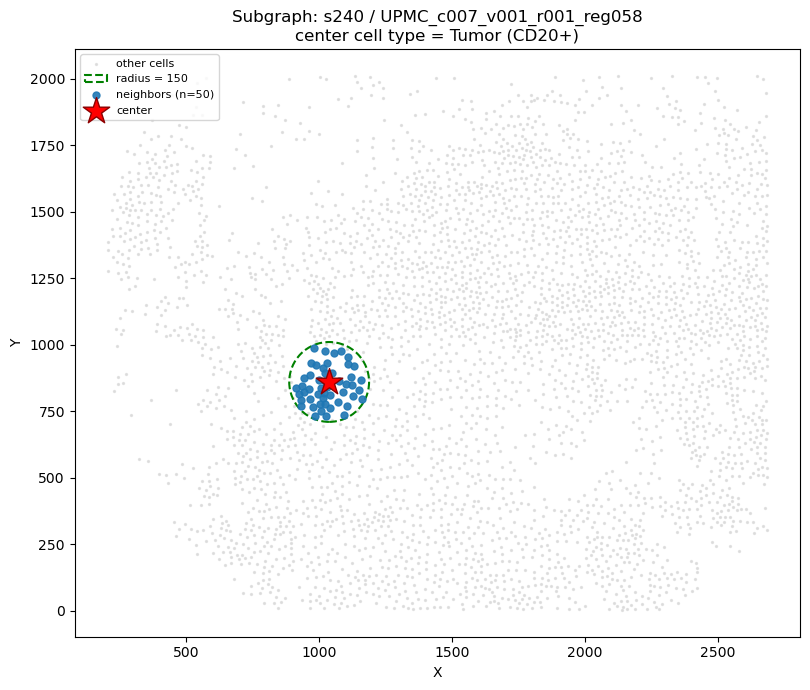

In [ ]:
# subgraph: sample center + neighbors, then show radius, center & neighbors
from spatial_sampler import SpatialSampler

region_idx = 0  # same as above (dataset[0]); change to view another region
region = dataset[region_idx]
sampler_viz = SpatialSampler(config)
subgraph = sampler_viz.sample_region(region)

if subgraph['original_center_idx'] is None or len(subgraph['coordinates']) == 0:
    print('No cells in region, skip subgraph viz.')
else:
    # original-space coordinates: center and neighbors
    center_idx = subgraph['original_center_idx']
    center_orig = region['coordinates'][center_idx]
    # subgraph['coordinates'][0] is center (0,0 relative); [1:] are neighbors
    rel_coords = subgraph['coordinates']
    neighbors_orig = center_orig + rel_coords[1:]
    radius = config.neighbor_distance_threshold  # 150

    coords_all = region['coordinates']
    cell_types_all = region['cell_types']
    unique_types = sorted(set(cell_types_all))
    cmap = plt.cm.get_cmap('tab20', max(len(unique_types), 1))
    type_to_color = {t: cmap(i) for i, t in enumerate(unique_types)}

    fig, ax = plt.subplots(figsize=(9, 7))
    # All cells in region (light grey)
    ax.scatter(coords_all[:, 0], coords_all[:, 1], c='lightgray', s=2, alpha=0.6, label='other cells')
    # Neighbor radius circle
    circle = plt.Circle(center_orig, radius, fill=False, color='green', linestyle='--', linewidth=1.5, label=f'radius = {radius}')
    ax.add_patch(circle)
    # Neighbors (blue)
    ax.scatter(neighbors_orig[:, 0], neighbors_orig[:, 1], c='C0', s=25, alpha=0.9, label=f'neighbors (n={len(neighbors_orig)})', zorder=3)
    # Center (red star)
    ax.scatter(center_orig[0], center_orig[1], marker='*', c='red', s=400, edgecolors='darkred', linewidths=1, label='center', zorder=5)

    ax.set_title(f'Subgraph: {region["study_name"]} / {region["region_name"]}\ncenter cell type = {subgraph["cell_types"][0] if subgraph["cell_types"] else "N/A"}')
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.legend(loc='upper left', fontsize=8)
    ax.set_aspect('equal')
    plt.tight_layout()
    plt.show()

## 4. Initialize Sampler, Masker & Embedder

In [23]:
from spatial_sampler import SpatialSampler
from intensity_masker import IntensityMasker
from esm_embedder import BiomarkerEmbedder

sampler  = SpatialSampler(config)
masker   = IntensityMasker(config)
embedder = BiomarkerEmbedder(config)
embedder.build_biomarker_vocab(list(dataset.all_biomarkers))
embedder = embedder.to(config.device)

print(f'Biomarker embedding dim  : {embedder.embedding_dim}')
print(f'Biomarker vocabulary size: {len(embedder.biomarker_to_idx)}')

Loaded 41 biomarkers from biomarker_sequences.csv
Loaded biomarker mapping from biomarker_name_mapping.json
Building biomarker vocabulary using learnable method...
Processing 41 valid biomarkers (EMPTY ones filtered out)
Building learnable embeddings...
Biomarker embedding dim  : 512
Biomarker vocabulary size: 41


In [ ]:
# Demo only: one round of spatial sampling + intensity masking
sample = sampler.sample_region(dataset[0])
print('Sampling result:')
print(f'  Center + neighbors : {len(sample["coordinates"])} cells')
print(f'  Coordinates shape  : {sample["coordinates"].shape}')
print(f'  Intensities shape  : {sample["intensities"].shape}')
print(f'  Center cell type   : {sample["cell_types"][0] if sample["cell_types"] else "N/A"}')

masked_sample = masker.mask_sample(sample)
n_masked = int(masked_sample['mask_flags'][0].sum())
n_total  = masked_sample['mask_flags'].shape[1]
print(f'\nMasking result:')
print(f'  Center cell: {n_masked}/{n_total} biomarkers masked')
print(f'  Masked biomarkers (first 5): {list(masked_sample["masked_items"].keys())[:5]}')

Sampling result:
  Center + neighbors : 51 cells
  Coordinates shape  : (51, 2)
  Intensities shape  : (51, 41)
  Center cell type   : Macrophage

Masking result:
  Center cell: 32/41 biomarkers masked
  Masked biomarkers (first 5): ['CD117', 'CD11b', 'CD11c', 'CD134', 'CD14']


## 5. Initialize Student & Teacher Models

In [25]:
from model import SpatialBiomarkerTransformer

student_model = SpatialBiomarkerTransformer(
    config,
    biomarker_embedder=embedder,
    intensity_masker=masker,
    is_teacher_model=False
).to(config.device)

teacher_model = SpatialBiomarkerTransformer(
    config,
    biomarker_embedder=embedder,
    intensity_masker=masker,
    is_teacher_model=True
).to(config.device)

teacher_model.load_state_dict(student_model.state_dict())
for param in teacher_model.parameters():
    param.requires_grad = False

total_params     = sum(p.numel() for p in student_model.parameters())
trainable_params = sum(p.numel() for p in student_model.parameters() if p.requires_grad)
print(f'Student — total params    : {total_params:,}')
print(f'Student — trainable params: {trainable_params:,}')
print(f'Teacher — total params    : {sum(p.numel() for p in teacher_model.parameters()):,} (frozen, EMA only)')

Student — total params    : 3,575,553
Student — trainable params: 3,554,561
Teacher — total params    : 3,575,553 (frozen, EMA only)


## 6. Build Training Subgraph Dataset

In [26]:
from torch.utils.data import DataLoader

print(f'Sampling {config.n_subgraphs_per_region} subgraphs per region...')
train_subgraphs = []
for i in tqdm(range(len(dataset)), desc='Sampling subgraphs'):
    region = dataset[i]
    for _ in range(config.n_subgraphs_per_region):
        train_subgraphs.append(sampler.sample_region(region))

np.random.shuffle(train_subgraphs)
print(f'Total subgraphs    : {len(train_subgraphs)}')

train_loader = DataLoader(
    train_subgraphs,
    batch_size=config.batch_size,
    shuffle=True,
    collate_fn=lambda x: x
)
print(f'Batches per epoch  : {len(train_loader)}')

Sampling 100 subgraphs per region...


Sampling subgraphs:   0%|          | 0/308 [00:00<?, ?it/s]

Total subgraphs    : 30800
Batches per epoch  : 482


## 7. Training Loop

In [27]:
import torch.nn as nn
import torch.optim as optim

recon_loss_fn   = nn.MSELoss()
distill_loss_fn = nn.MSELoss()

optimizer = optim.Adam(
    student_model.parameters(),
    lr=config.initial_lr,
    weight_decay=config.weight_decay,
    betas=(0.9, 0.999)
)

history = {'recon_loss': [], 'distill_loss': [], 'total_loss': []}
global_step = 0

def get_lr(step):
    if step < config.warmup_steps:
        return config.initial_lr + (config.lr - config.initial_lr) * (step / max(1, config.warmup_steps))
    return config.lr

def ema_update(student, teacher, momentum):
    with torch.no_grad():
        for s_p, t_p in zip(student.parameters(), teacher.parameters()):
            t_p.data = momentum * t_p.data + (1 - momentum) * s_p.data

print('Starting training...')
for epoch in range(config.num_epochs):
    student_model.train()
    teacher_model.eval()

    epoch_recon, epoch_distill, epoch_total = [], [], []

    pbar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{config.num_epochs}')
    for batch in pbar:
        global_step += 1

        current_lr = get_lr(global_step)
        for pg in optimizer.param_groups:
            pg['lr'] = current_lr

        optimizer.zero_grad()

        student_out = student_model(batch)
        with torch.no_grad():
            teacher_out = teacher_model(batch)

        recon_loss   = recon_loss_fn(student_out['recon_target'], student_out['recon_results'])
        distill_loss = distill_loss_fn(teacher_out['center_encoded'], student_out['center_encoded'])
        total_loss   = (config.reconstruction_loss_weight * recon_loss
                        + config.distillation_loss_weight * distill_loss)

        total_loss.backward()
        torch.nn.utils.clip_grad_norm_(student_model.parameters(), max_norm=1.0)
        optimizer.step()
        ema_update(student_model, teacher_model, config.ema_momentum)

        epoch_recon.append(recon_loss.item())
        epoch_distill.append(distill_loss.item())
        epoch_total.append(total_loss.item())

        pbar.set_postfix({
            'recon'  : f'{np.mean(epoch_recon[-20:]):.4f}',
            'distill': f'{np.mean(epoch_distill[-20:]):.4f}',
            'lr'     : f'{current_lr:.2e}'
        })

    history['recon_loss'].append(np.mean(epoch_recon))
    history['distill_loss'].append(np.mean(epoch_distill))
    history['total_loss'].append(np.mean(epoch_total))

    print(f'Epoch {epoch+1} | recon={history["recon_loss"][-1]:.4f}  '
          f'distill={history["distill_loss"][-1]:.4f}  '
          f'total={history["total_loss"][-1]:.4f}')

print('\nTraining complete!')

Starting training...


Epoch 1/10:   0%|          | 0/482 [00:00<?, ?it/s]

/opt/anaconda3/envs/torchen/lib/python3.10/site-packages/torch/nn/modules/transformer.py:508: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/NestedTensorImpl.cpp:182.)
  output = torch._nested_tensor_from_mask(


KeyboardInterrupt: 

## 8. Training Curves

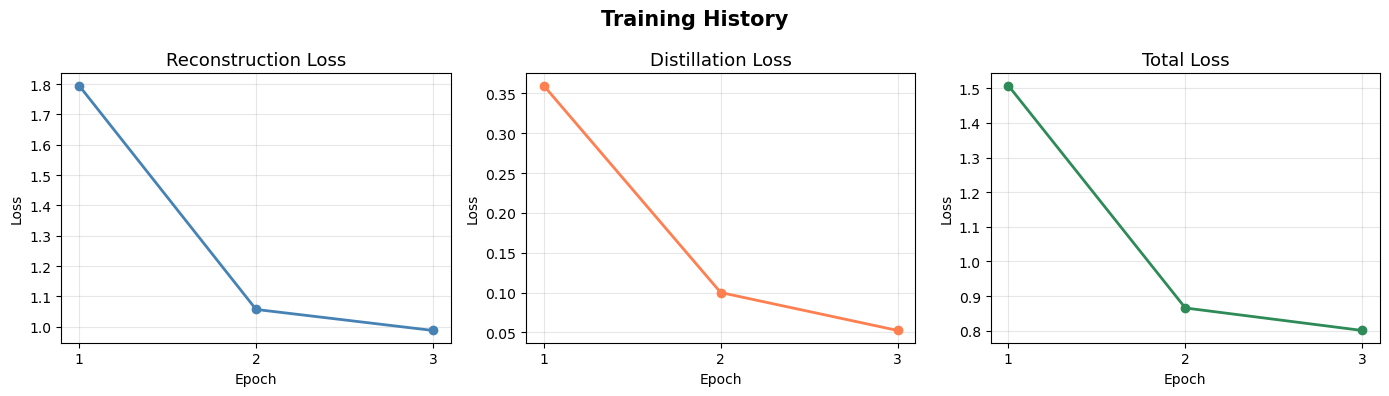

In [12]:
epochs = list(range(1, config.num_epochs + 1))

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, key, color, title in zip(
    axes,
    ['recon_loss', 'distill_loss', 'total_loss'],
    ['steelblue', 'coral', 'seagreen'],
    ['Reconstruction Loss', 'Distillation Loss', 'Total Loss']
):
    ax.plot(epochs, history[key], marker='o', color=color, linewidth=2)
    ax.set_title(title, fontsize=13)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.grid(True, alpha=0.3)
    ax.set_xticks(epochs)

plt.suptitle('Training History', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

## 9. Biomarker Reconstruction Quality

Compare the true vs. predicted intensity values for the masked biomarkers.

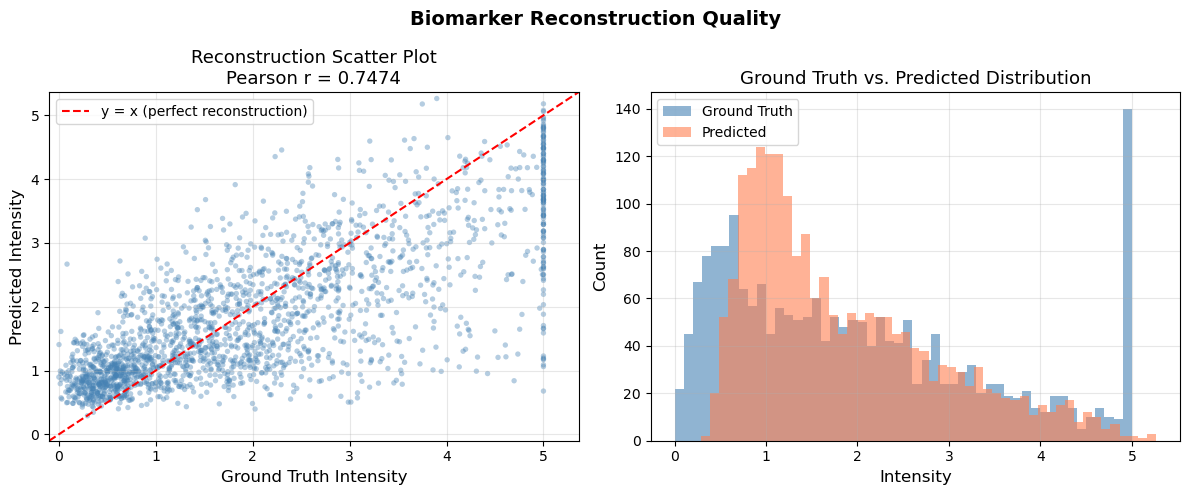

Pearson r  : 0.7474
MSE        : 0.915194
# samples  : 2048


In [13]:
student_model.eval()

test_batch = train_subgraphs[:config.batch_size]
with torch.no_grad():
    results = student_model(test_batch)

targets = results['recon_target'].cpu().numpy()
preds   = results['recon_results'].cpu().numpy()
corr    = np.corrcoef(targets, preds)[0, 1]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax = axes[0]
ax.scatter(targets, preds, alpha=0.4, s=15, c='steelblue', edgecolors='none')
lim = [min(targets.min(), preds.min()) - 0.1, max(targets.max(), preds.max()) + 0.1]
ax.plot(lim, lim, 'r--', linewidth=1.5, label='y = x (perfect reconstruction)')
ax.set_xlim(lim); ax.set_ylim(lim)
ax.set_xlabel('Ground Truth Intensity', fontsize=12)
ax.set_ylabel('Predicted Intensity', fontsize=12)
ax.set_title(f'Reconstruction Scatter Plot\nPearson r = {corr:.4f}', fontsize=13)
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.hist(targets, bins=50, alpha=0.6, label='Ground Truth', color='steelblue')
ax.hist(preds,   bins=50, alpha=0.6, label='Predicted',    color='coral')
ax.set_xlabel('Intensity', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('Ground Truth vs. Predicted Distribution', fontsize=13)
ax.legend()
ax.grid(True, alpha=0.3)

plt.suptitle('Biomarker Reconstruction Quality', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Pearson r  : {corr:.4f}')
print(f'MSE        : {np.mean((targets - preds)**2):.6f}')
print(f'# samples  : {len(targets)}')

## 10. Cell Embedding Visualization (t-SNE)

Extract `center_encoded` from the student model — the final cell representation used for downstream tasks.

Extracting embeddings:   0%|          | 0/8 [00:00<?, ?it/s]

Embedding matrix shape: (500, 256)
Running t-SNE...


/var/folders/g4/w7sz7ldj4yb673_hlj0jrc700000gn/T/ipykernel_95922/487150146.py:25: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap           = plt.cm.get_cmap('tab20', len(unique_labels))


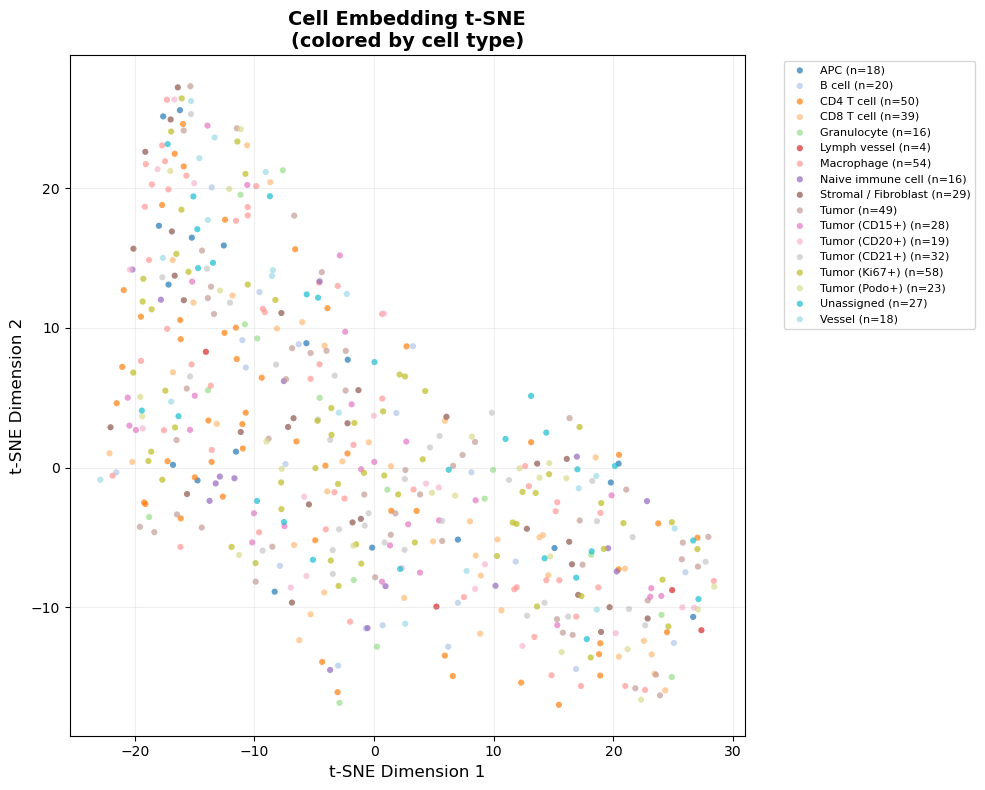

In [14]:
from sklearn.manifold import TSNE

student_model.eval()

all_embeddings = []
all_labels = []
eval_subgraphs = train_subgraphs[:500]

for i in tqdm(range(0, len(eval_subgraphs), config.batch_size), desc='Extracting embeddings'):
    batch = eval_subgraphs[i:i+config.batch_size]
    with torch.no_grad():
        out = student_model(batch)
    all_embeddings.append(out['center_encoded'].cpu().numpy())
    for sample in batch:
        all_labels.append(sample['cell_types'][0] if sample['cell_types'] else 'unknown')

embeddings = np.concatenate(all_embeddings, axis=0)
print(f'Embedding matrix shape: {embeddings.shape}')

print('Running t-SNE...')
tsne  = TSNE(n_components=2, perplexity=min(30, len(embeddings)-1), random_state=42)
emb_2d = tsne.fit_transform(embeddings)

unique_labels  = sorted(set(all_labels))
cmap           = plt.cm.get_cmap('tab20', len(unique_labels))
label_to_color = {l: cmap(i) for i, l in enumerate(unique_labels)}

fig, ax = plt.subplots(figsize=(10, 8))
for label in unique_labels:
    mask = np.array(all_labels) == label
    ax.scatter(emb_2d[mask, 0], emb_2d[mask, 1],
               c=[label_to_color[label]],
               label=f'{label} (n={mask.sum()})',
               s=20, alpha=0.7, edgecolors='none')

ax.set_title('Cell Embedding t-SNE\n(colored by cell type)', fontsize=14, fontweight='bold')
ax.set_xlabel('t-SNE Dimension 1', fontsize=12)
ax.set_ylabel('t-SNE Dimension 2', fontsize=12)
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

## 11. Save Checkpoint (Optional)

In [ ]:
SAVE_MODEL = False  # Set to True to save

if SAVE_MODEL:
    os.makedirs('checkpoints', exist_ok=True)
    torch.save({
        'student_state_dict': student_model.state_dict(),
        'teacher_state_dict': teacher_model.state_dict(),
        'optimizer'         : optimizer.state_dict(),
        'history'           : history,
        'biomarker_vocab'   : embedder.biomarker_to_idx,
    }, 'checkpoints/demo_checkpoint.pth')
    print('Checkpoint saved to checkpoints/demo_checkpoint.pth')
else:
    print('SAVE_MODEL=False — skipping checkpoint.')

SAVE_MODEL=False — skipping checkpoint.
